<a href="https://colab.research.google.com/github/kars542-byte/Algoritmos_Optimizacion_V1/blob/main/Another_copy_of_Trabajo_Pr%C3%A1ctico_Algoritmos(V2)_Kenneth_Rangel_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Kenneth Rangel Salazar  <br>
Url: https://github.com/kars542-byte/Algoritmos_Optimizacion_V1/blob/42439a92de502698279779768b85d82065a9e506/Another_copy_of_Trabajo_Pr%C3%A1ctico_Algoritmos(V2)_Kenneth_Rangel_2.ipynb<br>
Google Colab: https://colab.research.google.com/drive/1z8c2UPJ8EddIcAi53fE4TJ_P4rq-whrb?usp=sharing <br>
Problema:
>1. Sesiones de doblaje <br>

Descripción del problema:(copiar enunciado)

Problema 1. Organizar sesiones de doblaje(I)
• Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en
las tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de
doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el
estudio de grabación independientemente del número de tomas que se graben. No es
posible grabar más de 6 tomas por día. El objetivo es planificar las sesiones por día de
manera que el gasto por los servicios de los actores de doblaje sea el menor posible. Los
datos son:
Número de actores: 10
Número de tomas : 30
Actores/Tomas : https://bit.ly/36D8IuK
- 1 indica que el actor participa en la toma
- 0 en caso contrario







                                        

#Modelo
- ¿Como represento el espacio de soluciones?
## El espacio de soluciones es un vector de 30 posiciones, este vector de 30 posiciones implica que la posicion es la toma (de 1 a 30), el valor dentro de la posicion es el dia asignado (de 1 a 30 dias). El espacio de soluciones lo he pensado en un vector que me dice que dia se toma cada toma pero el objetivo final es saber cual de los vectores tiene un costo mas bajo.
- ¿Cual es la función objetivo?
## La funcion objetivo es calcular el costo de cada vector (cada individuo), de manera que se pueda comparar soluciones y se pueda identificar tambien cuales son las funciones que pueden tener rol de padres antes del proceso de cruce.
- ¿Como implemento las restricciones?
## Las restricciones se implementan considerando que por ejemplo:
## 1. Un dia no puede repetirse mas de 6 veces, sino quiere decir que existen mas de 6 tomas asi que esa solucion puede descartarse colocandole un costo muy alto.
## 2. La cantidad maxima de dias, considerando que son 30 tomas, la he establecido en 30 dias y la cantidad minima de dias, considerando que son 6 tomas por dia nos da 5 dias minimo para la ejecucion de la obra y disposicion de dobles.
## 3. Considerar que el numero de actores es finito, entonces defino la tabla de actores en un vector que tenga 30 posiciones (las tomas), y dentro de cada posicion un vector que tenga 10 posiciones (los actores), finalmente el valor de cada posicion del vector de 10 posiciones nos indica con "1" o "0" si ese actor asiste o no al dia de grabacion.

In [1]:
#Respuesta
import random   #Libreria para generar numeros y listas aleatorias
import copy     #Permite hacer copias de objetos en python: listas, diccionarios,...
import math     #manejo de numeros para redondeo y para precision
import matplotlib.pyplot as plt
import numpy as np

num_tomas = 30
actores = 10
max_dias = 30
num_poblacion = 100 #valor para funcion generar_poblacion()
mutacion = 0.1 #cercano a x-men
elitismo = True
generaciones = 1000
tomas_actor = [[1,1,1,1,1,0,0,0,0,0],[0,0,1,1,1,0,0,0,0,0],[0,1,0,0,1,0,1,0,0,0],[1,1,0,0,0,0,1,1,0,0],[0,1,0,1,0,0,0,1,0,0],[1,1,0,1,1,0,0,0,0,0],[1,1,0,1,1,0,0,0,0,0],[1,1,0,0,0,1,0,0,0,0],[1,1,0,1,0,0,0,0,0,0],[1,1,0,0,0,1,0,0,1,0],[1,1,1,0,1,0,0,1,0,0],[1,1,1,1,0,1,0,0,0,0],[1,0,0,1,1,0,0,0,0,0],[1,0,1,0,0,1,0,0,0,0],[1,1,0,0,0,0,1,0,0,0],[0,0,0,1,0,0,0,0,0,1],[1,0,1,0,0,0,0,0,0,0],[0,0,1,0,0,1,0,0,0,0],[1,0,1,0,0,0,0,0,0,0],[1,0,1,1,1,0,0,0,0,0],[0,0,0,0,0,1,0,1,0,0],[1,1,1,1,0,0,0,0,0,0],[1,0,1,0,0,0,0,0,0,0],[0,0,1,0,0,1,0,0,0,0],[1,1,0,1,0,0,0,0,0,1],[1,0,1,0,1,0,0,0,1,0],[0,0,0,1,1,0,0,0,0,0],[1,0,0,1,0,0,0,0,0,0],[1,0,0,0,1,1,0,0,0,0],[1,0,0,1,0,0,0,0,0,0]]

In [2]:
#Funciones de la Actividad Guiada Algoritmos Geneticos
#Se genera una solucion aleatoria con comienzo en una solucion aleatoria para cada una de las tomas
#Importante, cada solucion va desde la toma 1 a la toma 30, dentro de cada toma se considera su valor numerico que es el dia de la toma.
def crear_solucion():
  solucion = []
  i = 0
  for i in range(num_tomas): #el for asegura el relleno de las 30 tomas con el valor aleatorio
      dia = random.randint(1, max_dias) #considera un dia aleatorio para la realizacion de la toma
      solucion.append(dia)
  return solucion
#i = 0
#for i in range(15):
#print(crear_solucion())
def calcular_costo(solucion):
  costo = 0
  tomas_dia = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0] #Tiene 30 posiciones para usar los 30 dias de referencia efectivamente y saber cuantas tomas hay cada dia. Estructura estatica.
  actor_dias = [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
  dia = 0
  penalidad = 0

  #calculo de penalidad por exceder 6 tomas / descarte por penalidad
  for dia in solucion: #toma el dia dentro de la variable solucion (del 1 al 30)
    tomas_dia[dia-1] += 1 #guarda el conteo en la posicion correcta dia - 1
  for i in range(30):
    if tomas_dia[i] > 6:
      penalidad = penalidad + tomas_dia[i] - 6 #con esto veo la cantidad de tomas que se excedieron ese dia
  #calculo de penalidad por exceder 6 tomas / descarte por penalidad

  #calculo de costo por cada actor
  for toma_id in range(30):
    dia_toma = solucion[toma_id] # día que le tocó a esta toma
    dia_toma = dia_toma - 1
    for actor_id in range(10):
        if tomas_actor[toma_id][actor_id] == 1:
            actor_dias[actor_id][dia_toma] = 1  # marcar que trabaja ese día
  for i in range(actores):
    costo = costo + sum(actor_dias[i])
  costo = costo + penalidad*1000 #consideramos el costo por actor y consideramos darle peso a la penalidad por mas de 6 tomas para descartarlo
  return costo

In [3]:
#Genera una poblacion inicial de soluciones de tamaño num_poblacion.
def generar_poblacion(num_poblacion):
  poblacion = []
  i = 1
  for i in range(num_poblacion):
        poblacion.append(crear_solucion())
  return poblacion

#Evalua la población y devuelve el mejor individuo
def Evaluar_Poblacion(poblacion):
  mejor_costo = 1000000 #valor muy grande para comparar contra caso inicial donde no hay historico costo
  mejor_solucion = None
  costos = []
  for cada_solucion in poblacion: #revisa cada solucion de la poblacion
    cada_costo = calcular_costo(cada_solucion) #calcula el costo de cada solucion evaluada y luego lo mete en la variable costos (esta son todos los costos de cada individuo de la poblacion)
    costos.append(cada_costo)
    if cada_costo < mejor_costo: #comparador para hacer el vs contra el mejor costo al momento
      mejor_costo = cada_costo #se define el mejor nuevo costo
      mejor_solucion = copy.deepcopy(cada_solucion) #copiamos la solucion completa de ese costo ganador
  #print(mejor_solucion,"Soluciones--->Len",len(mejor_solucion),"; Mejor Costo--->",mejor_costo,"; Con vector de costos--->",costos,"; Len",len(costos))
  return mejor_solucion, mejor_costo, costos #devolvemos la solucion (el individuo ganador), mejor costo de referencia de esa solucion y la estructura de los costos de la poblacion ganadora

#Funcion de cruce. Recibe una poblacion(lista de soluciones) y devuelve la población ampliada con los hijos.
def Cruzar_nueva_pobla(poblacion,mejor_solucion,num_poblacion,elitismo,mutacion,num_tomas,max_dias):
  #Inciamos el ciclo de generaciones, primero inicializamos el arreglo de la nueva_poblacion[]
  nueva_poblacion = []
  #creacion de la nueva poblacion(incluyo primer elemento solucion viene de la mejor solucion y luego entra a while con pura descendencia/cruce/mutacion)
  nueva_poblacion.append(copy.deepcopy(mejor_solucion))

  #Usa while para crear una nueva poblacion cruzada con descencdencia y mutacion.
  while len(nueva_poblacion) < num_poblacion:
    #Descendencia (cruce) de la poblacion
    (hijo1, hijo2) = Descendencia(poblacion,mejor_solucion,elitismo)
    #Mutacion de la poblacion
    (hijo1_m, hijo2_m) = Mutar(hijo1,hijo2,mutacion,num_tomas,max_dias)

    # Agregar UN hijo si falta espacio
    if len(nueva_poblacion) < num_poblacion:
      nueva_poblacion.append(hijo1_m)
    # Agregar el segundo hijo si aún falta espacio
    if len(nueva_poblacion) < num_poblacion:
      nueva_poblacion.append(hijo2_m)
  return nueva_poblacion

#Funcion de Cruce y Descendencia para generar hijos a partir de 2 padres:
#Se elige el metodo de 1-punto de corte pero es posible usar otros n-puntos, uniforme, dependiendo del problema
#Se considera el parametro para usar el criterio de elitismo de seleccion del mejor padre de la mejor solucion actual
def Descendencia(poblacion,mejor_solucion,elitismo):
  if elitismo == True:
    padre1 = mejor_solucion #aca aseguro usar la mejor solucion actual del algoritmo
    padre2 = random.choice(poblacion) #aca tomo una solucion aleatoria de la poblacion que se utiliza actualmente en el while/bucle principal
  else:
    padre1 = random.choice(poblacion) #aca tomo una solucion aleatoria de la poblacion que se utiliza actualmente en el while/bucle principal
    padre2 = random.choice(poblacion) #aca tomo una solucion aleatoria de la poblacion que se utiliza actualmente en el while/bucle principal
  ind_corte = random.randint(1, num_tomas - 1) #aca veo aleatoriamente donde partir el cruce
  hijo1 = padre1[:ind_corte] + padre2[ind_corte:] #generacion hijo1
  hijo2 = padre2[:ind_corte] + padre1[ind_corte:] #generacion hijo2
  return hijo1, hijo2

#Para el operador de cruce 1-punto los hijos generados no son soluciones(algunos nodos se repiten y otros no están)
#def Factibilizar(solucion,problem): #no la usamos porque estamos poniendo penalidad si es mas de 6 tomas
  #return 0

#Funcion de mutación. Se eligen dos nodos y se intercambia. Se podrian añadir otros operaradores
# Se hace mutaciones mutacion% de las veces
def Mutar(hijo1,hijo2,mutacion,num_tomas,max_dias):
  hijo1_m = copy.deepcopy(hijo1)
  hijo2_m = copy.deepcopy(hijo2)
  num_a_mutar = int(round(mutacion * num_tomas)) #aca calculo cuantas tomas debo mutar de las 30 (num_tomas)
  tomas_a_mutar = random.sample(range(num_tomas), num_a_mutar) #aca almaceno la cantidad de tomas que puedo mutar (tomo samples de un rango de 0 a 29)
  i = 0
  for i in tomas_a_mutar:
    hijo1_m[i] = random.randint(1, max_dias)
    hijo2_m[i] = random.randint(1, max_dias)
  return hijo1_m, hijo2_m

#Funcion de seleccion de la población. Recibe como parametro una poblacion y
# devuelve una poblacion a la que se ha eliminado individuos poco aptos(fitness alto) y para mantener una poblacion estable de N individuos
# Se tiene en cuenta el porcentaje elitismo pasado como parametro
# Para los individuos que no son de la elite podríamos usar una selección de ruleta(proporcional a su fitness)
#def Seleccionar(problem,poblacion, N, elitismo):
  #return 0


Generacion # 1001 
El vector de costos es: [35, 58, 46, 50, 1036, 51, 46, 42, 56, 53, 45, 1038, 47, 41, 41, 44, 51, 40, 53, 42, 48, 41, 40, 46, 51, 47, 1047, 49, 2037, 56, 44, 1047, 49, 42, 40, 42, 48, 43, 44, 52, 1041, 49, 52, 43, 49, 58, 48, 39, 48, 52, 42, 42, 55, 1060, 50, 45, 55, 48, 46, 51, 43, 42, 52, 1038, 57, 49, 41, 44, 47, 45, 55, 49, 45, 41, 54, 38, 57, 43, 2041, 1054, 45, 1044, 52, 44, 47, 1052, 50, 41, 1041, 45, 1051, 42, 48, 42, 48, 48, 43, 44, 49, 54] 
con costo  35 

Generacion # 1001 
El vector de costos es: [54, 72, 72, 80, 71, 67, 74, 83, 1065, 67, 76, 71, 69, 78, 77, 76, 68, 74, 73, 73, 70, 70, 75, 80, 73, 74, 77, 73, 71, 69, 75, 72, 68, 79, 75, 71, 67, 1059, 72, 65, 77, 70, 77, 66, 70, 73, 76, 71, 77, 70, 77, 69, 74, 75, 81, 78, 66, 72, 74, 78, 72, 72, 71, 79, 71, 76, 59, 77, 70, 68, 76, 72, 78, 74, 65, 77, 73, 70, 81, 82, 75, 77, 74, 68, 76, 81, 75, 73, 73, 73, 76, 76, 69, 81, 71, 75, 79, 67, 74, 79] 
con costo  54 

Generacion # 1001 
El vector de costos es: [58

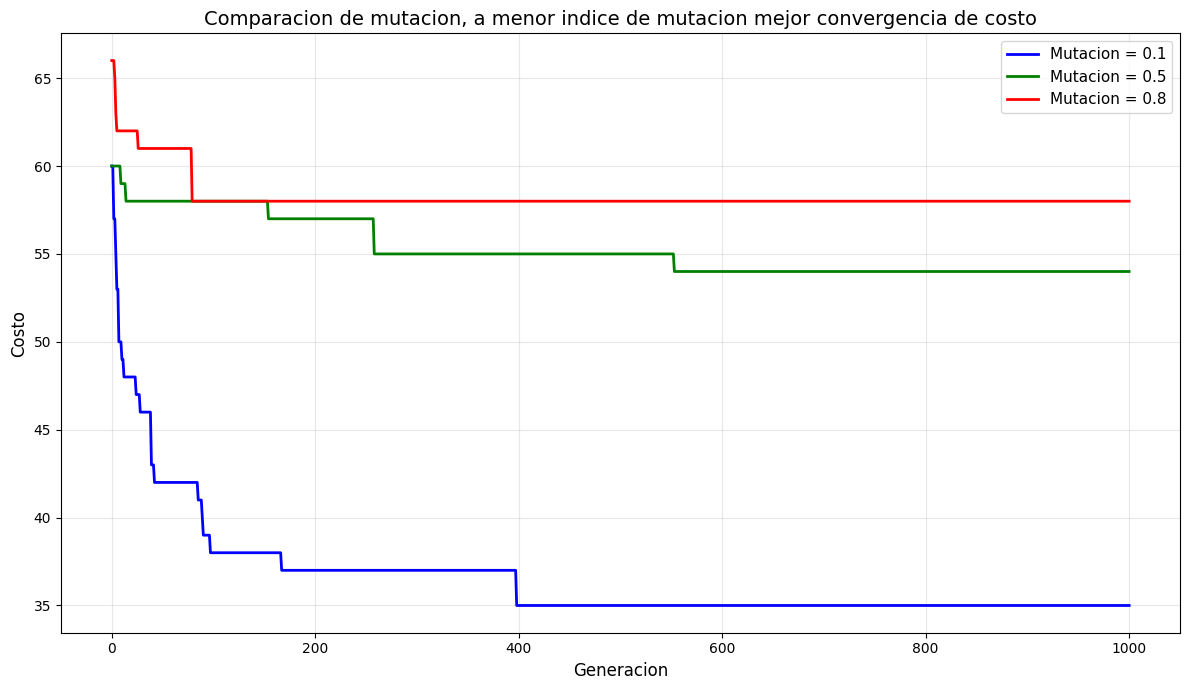

Generacion # 1001 
El vector de costos es: [35, 44, 37, 57, 52, 1042, 48, 44, 44, 49, 46, 44, 48, 48, 52, 1050, 40, 46, 54, 42, 52, 44, 46, 44, 44, 48, 43, 47, 48, 48, 58, 46, 49, 1046, 52, 57, 45, 55, 54, 1045, 44, 1048, 45, 1046, 38, 44, 43, 48, 48, 46, 42, 44, 42, 41, 1048, 49, 45, 46, 54, 51, 39, 51, 1043, 48, 51, 1040, 48, 44, 57, 1043, 47, 41, 53, 54, 43, 1042, 47, 47, 54, 46, 42, 48, 46, 48, 42, 59, 47, 45, 44, 51, 42, 49, 47, 45, 49, 51, 48, 41, 51, 46] 
con costo  35 

Generacion # 1001 
El vector de costos es: [51, 76, 77, 78, 83, 72, 69, 76, 78, 73, 83, 74, 73, 83, 74, 74, 62, 74, 75, 82, 75, 71, 83, 73, 82, 75, 72, 76, 77, 73, 87, 73, 74, 73, 81, 76, 75, 75, 73, 83, 74, 71, 72, 86, 81, 79, 78, 73, 61, 84, 75, 75, 76, 71, 72, 79, 72, 66, 65, 80, 77, 80, 82, 79, 74, 72, 70, 74, 76, 67, 81, 72, 76, 84, 74, 77, 72, 80, 72, 70, 73, 80, 78, 81, 74, 74, 77, 81, 81, 80, 81, 65, 81, 74, 73, 82, 76, 76, 76, 72] 
con costo  51 



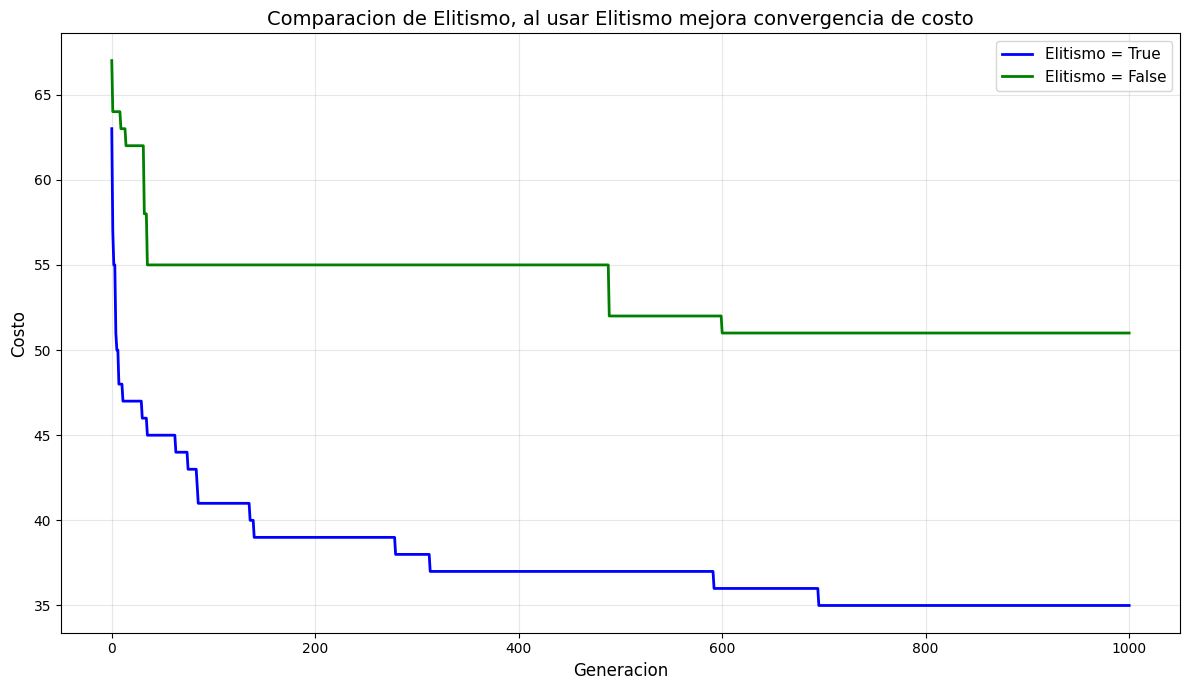

Generacion # 1001 
El vector de costos es: [36, 45, 41, 51, 48, 45, 47, 52, 49, 1044, 60, 48, 56, 44, 44, 53, 47, 49, 42, 45, 1047, 49, 45, 55, 48, 54, 41, 40, 43, 46, 44, 58, 41, 42, 55, 47, 45, 2044, 50, 45, 43, 47, 1047, 58, 46, 50, 43, 53, 45, 1043, 51, 59, 1042, 51, 45, 46, 55, 50, 52, 54, 1047, 49, 54, 50, 1042, 53, 47, 50, 44, 45, 1042, 1041, 57, 53, 2038, 50, 44, 50, 47, 47, 50, 47, 56, 44, 48, 51, 48, 1044, 49, 42, 50, 44, 51, 41, 49, 52, 1047, 44, 40, 1038] 
con costo  36 

Generacion # 1001 
El vector de costos es: [39, 1042, 61, 44, 60, 49, 44, 53, 60, 1053, 51, 49, 1051, 61, 45, 48, 53, 56, 50, 47, 42, 48, 62, 50, 43, 46, 50, 52, 45, 49, 63, 50, 55, 64, 51, 50, 53, 48, 52, 53, 47, 47, 62, 48, 52, 54, 1041, 55, 49, 50] 
con costo  39 

Generacion # 1001 
El vector de costos es: [38, 2043, 50, 1048, 50, 48, 47, 1049, 1041, 1049] 
con costo  38 



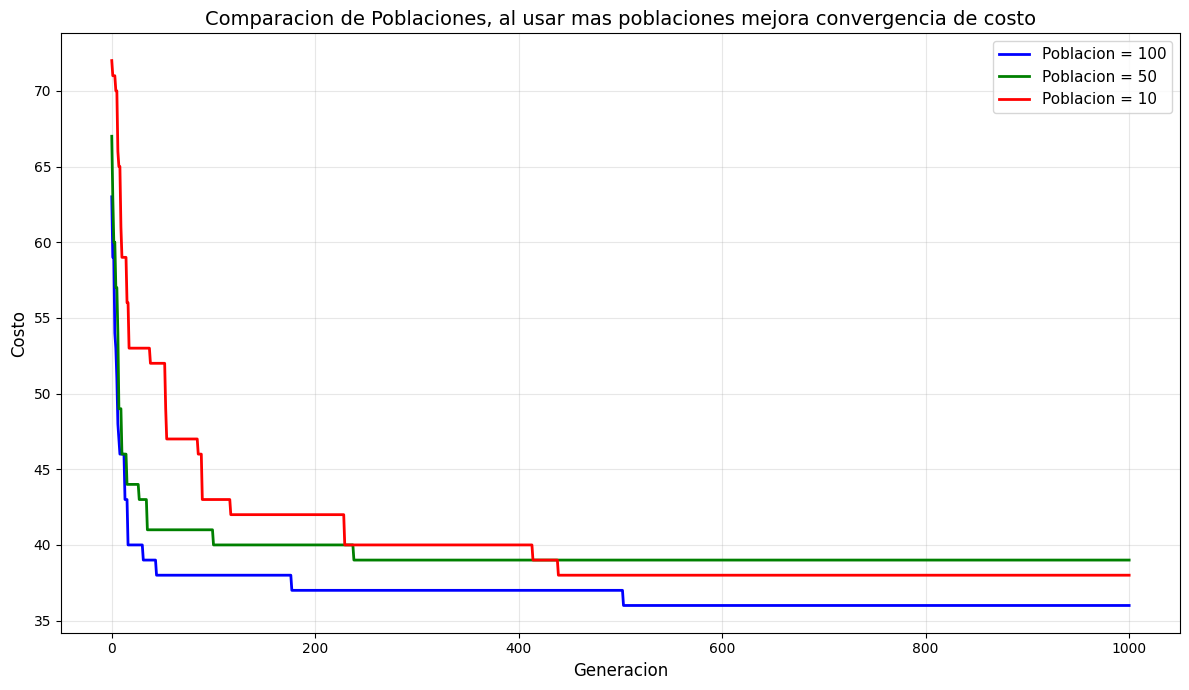

In [4]:
#Funcion principal del algoritmo genetico
#######################################################
def algoritmo_genetico(tomas_actor,num_poblacion,mutacion,elitismo,generaciones,num_tomas,actores,max_dias):
  #tomas_actor = datos del problema
  #num_poblacion = tamaño de la poblacion
  #mutacion = probabilidad de una mutación
  #elitismo = usar estrategia de elitismo (T or F), se usa padre1 como el mejor de la poblacion (alfa)
  #generaciones = nº de generaciones a generar para finalizar
  #num_tomas = cantidad total de tomas
  #actores = numero de actoresde respaldo para generar costos
  #max_dias = estimado maximo de diasque podria durar todo, peor caso

  #Genera la poblacion inicial
  poblacion = generar_poblacion(num_poblacion)

  #Inicializamos valores para la mejor solucion
  (mejor_solucion, mejor_costo, costos) = Evaluar_Poblacion(poblacion)

  #print(crear_solucion())

  #Condicion de parada
  parar = False
  n=0

  #guardo el historico de la generacion para poder graficar
  historico_generacion = []

  while(parar == False) :

    #Aca hacemos el cruce de la poblacion original contra los parametros del problema y obtenemos la nueva poblacion
    nueva_poblacion = Cruzar_nueva_pobla(poblacion,mejor_solucion,num_poblacion,elitismo,mutacion,num_tomas,max_dias)

    #Aca evaluamos la nueva poblacion
    (mejor_solucion, mejor_costo, costos) = Evaluar_Poblacion(nueva_poblacion)

    #Aca actualizamos poblacion = nueva poblacion para la siguiente iteracion del while
    poblacion = nueva_poblacion

    #print("Generacion #", n, "\nEl vector de costos es:" , costos, "\ncon costo " , mejor_costo, "\n")
    #print("Generacion #", n,"\ncon costo " , mejor_costo, "\n")

    #Guardamos el historico de generacion para poder graficar por caso de plan genetico
    historico_generacion.append(mejor_costo)

    #Numero de generaciones. Criterio de parada
    if n==generaciones:
      parar = True
    n +=1

  #Se imprime la solucion final
  print("Generacion #", n, "\nEl vector de costos es:" , costos, "\ncon costo " , mejor_costo, "\n")

  return mejor_solucion, historico_generacion

#Exploracion de soluciones sobre parametros de entrada, Grupo sobre mutacion incremental (0.1, 0.5, 0.8)
sol1, historico1 = algoritmo_genetico(tomas_actor,num_poblacion,mutacion,elitismo,generaciones,num_tomas,actores,max_dias)
sol2, historico2 = algoritmo_genetico(tomas_actor,num_poblacion,0.5,elitismo,generaciones,num_tomas,actores,max_dias)
sol3, historico3 = algoritmo_genetico(tomas_actor,num_poblacion,0.8,elitismo,generaciones,num_tomas,actores,max_dias)

#Graficar las 3 curvas
plt.figure(figsize=(12, 7))
plt.plot(historico1, 'b-', linewidth=2, label='Mutacion = 0.1')
plt.plot(historico2, 'g-', linewidth=2, label='Mutacion = 0.5')
plt.plot(historico3, 'r-', linewidth=2, label='Mutacion = 0.8')

#Formato
plt.xlabel('Generacion', fontsize=12)
plt.ylabel('Costo', fontsize=12)
plt.title('Comparacion de mutacion, a menor indice de mutacion mejor convergencia de costo', fontsize=14)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Exploracion de soluciones sobre parametros de entrada, Grupo sobre Elitismo = True or False
sol4, historico4 = algoritmo_genetico(tomas_actor,num_poblacion,mutacion,elitismo,generaciones,num_tomas,actores,max_dias)
sol5, historico5 = algoritmo_genetico(tomas_actor,num_poblacion,mutacion,False,generaciones,num_tomas,actores,max_dias)

#Graficar las 3 curvas
plt.figure(figsize=(12, 7))
plt.plot(historico4, 'b-', linewidth=2, label='Elitismo = True')
plt.plot(historico5, 'g-', linewidth=2, label='Elitismo = False')

#Formato
plt.xlabel('Generacion', fontsize=12)
plt.ylabel('Costo', fontsize=12)
plt.title('Comparacion de Elitismo, al usar Elitismo mejora convergencia de costo', fontsize=14)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Exploracion de soluciones sobre parametros de entrada, menor tamano de poblacion y mas generaciones
sol6, historico6 = algoritmo_genetico(tomas_actor,num_poblacion,mutacion,elitismo,generaciones,num_tomas,actores,max_dias)
sol7, historico7 = algoritmo_genetico(tomas_actor,50,mutacion,elitismo,generaciones,num_tomas,actores,max_dias)
sol8, historico8 = algoritmo_genetico(tomas_actor,10,mutacion,elitismo,generaciones,num_tomas,actores,max_dias)

#Graficar las 3 curvas
plt.figure(figsize=(12, 7))
plt.plot(historico6, 'b-', linewidth=2, label='Poblacion = 100')
plt.plot(historico7, 'g-', linewidth=2, label='Poblacion = 50')
plt.plot(historico8, 'r-', linewidth=2, label='Poblacion = 10')

#Formato
plt.xlabel('Generacion', fontsize=12)
plt.ylabel('Costo', fontsize=12)
plt.title('Comparacion de Poblaciones, al usar mas poblaciones mejora convergencia de costo', fontsize=14)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Análisis
- ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de soluciones.
## La complejidad del problema es exponencial, primero hay que considerar cuantos dias puede demorar el proceso, maximo 30 dias = D. Luego hay que considerar cual toma podria tocar cada dia, seria considerar N = 30. La complejidad podria expresarse como Dᴺ = 30ᴺ = 2.05 x 10ᴮ, con B = 44. Esto representa una cantidad de soluciones muy grande.
## Complejidad: exponencial.
## Orden de complejidad: 10ᴮ con B = 44.
## Contabilizar espacio de soluciones = 2.05 x 10ᴮ, con B = 44.

#Diseño
- ¿Que técnica utilizo? ¿Por qué?
##Se utilizo algoritmos geneticos dada la complejidad y que no es facil ver el universo de soluciones o como acotarlas o generar subconjuntos de problemas que ayuden. Seria imposible recorrer solucion por solucion de forma optima y rapida porque tendria que iterar muchas veces el algoritmo.
##El algoritmo genetico tiene la facilidad de implementacion y la aleatoriedad de escenarios que permite que generacion tras generacion se acerque mas una posible optimizacion de solucion.
##Porque como hemos visto en las referencias y casos, la facilidad de representacion de las soluciones permite que se use la estrategia de cruce para poder generar nuevos escenarios y con esos escenarios lograr que la funcion objetivo pueda comparar los score que obtienen las soluciones y asi lograr mejorar geneticamente las muestras mas efectivas.